In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
%matplotlib inline

df = pd.read_parquet("../data/processed/ball_by_ball.parquet")
print(df.shape)
print(df.columns.tolist())


(294579, 56)
['match_id', 'season_x', 'start_date', 'venue_x', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'total_runs_ball', 'is_wicket', 'is_legal_ball', 'is_four', 'is_six', 'balls_per_over', 'team', 'gender', 'season_y', 'date', 'event', 'match_number', 'venue_y', 'city', 'toss_winner', 'toss_decision', 'player_of_match', 'umpire', 'reserve_umpire', 'tv_umpire', 'match_referee', 'winner', 'winner_wickets', 'winner_runs', 'outcome', 'eliminator', 'method', 'cum_runs', 'cum_legal_balls', 'cum_wickets_after', 'cum_wickets', 'overs_completed', 'balls_remaining', 'current_run_rate']


In [2]:
drop_cols = ["season_y", "venue_y"]

df = df.drop(columns=drop_cols)

df = df.rename(columns={
    "season_x": "season",
    "venue_x": "venue"
})

In [3]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

other_wicket_type         294579
other_player_dismissed    294579
eliminator                290602
method                    290448
outcome                   289774
player_dismissed          279960
wicket_type               279960
winner_runs               158868
winner_wickets            140516
match_number               16713
city                       12355
reserve_umpire              5744
winner                      4805
tv_umpire                    930
player_of_match              828
dtype: int64

In [4]:
df[[
    "match_id",
    "innings",
    "ball",
    "cum_runs",
    "cum_wickets"
]].head(20)

,match_id,innings,ball,cum_runs,cum_wickets
0,1082591,1,0.1,0,0
1,1082591,1,0.2,0,0
2,1082591,1,0.3,4,0
3,1082591,1,0.4,4,0
4,1082591,1,0.5,6,0
5,1082591,1,0.6,6,0
6,1082591,1,0.7,7,0
7,1082591,1,1.1,8,0
8,1082591,1,1.2,12,0
9,1082591,1,1.3,13,0


In [5]:
df["over"] = df["ball"].astype(int)

In [6]:
df["total_runs_ball"].value_counts().sort_index()

total_runs_ball
0    100876
1    122532
2     19237
3       988
4     34666
5       593
6     15591
7        96
Name: count, dtype: int64

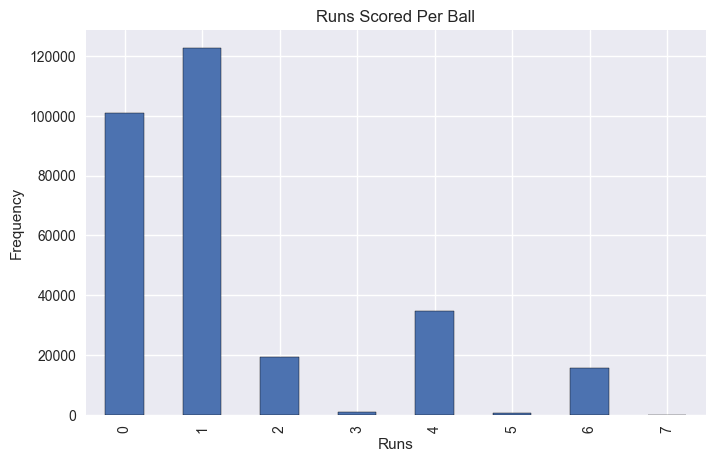

In [7]:
plt.figure(figsize=(8, 5))

df["total_runs_ball"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Runs Scored Per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.savefig("runs_per_ball.png", dpi=150)

plt.show()

### Observation

- Dot balls are the most common outcome in IPL matches.
- Singles occur much more frequently than boundaries.
- High scoring deliveries like sixes are relatively rare compared to low scoring balls.

In [8]:
df["is_wicket"].value_counts()

is_wicket
0    279960
1     14619
Name: count, dtype: int64

In [9]:
df["wicket_type"].value_counts()

wicket_type
caught                   9269
bowled                   2446
run out                  1183
lbw                       878
caught and bowled         409
stumped                   387
retired hurt               19
hit wicket                 18
retired out                 6
obstructing the field       4
Name: count, dtype: int64

### Observation

- Most deliveries do not result in wickets.
- Caught dismissals are the most common wicket type in IPL matches.
- Run outs and stumpings are relatively less frequent.

In [10]:
matches_per_season = (
    df.groupby("season")["match_id"]
    .nunique()
    .sort_index()
)

matches_per_season

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
2026       70
Name: match_id, dtype: int64

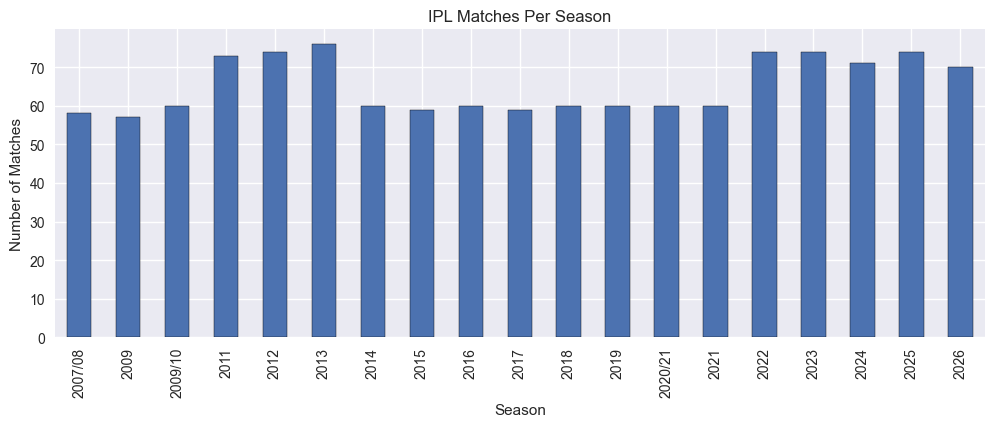

In [11]:
matches_per_season.plot(
    kind="bar",
    figsize=(12, 4),
    edgecolor="black"
)

plt.title("IPL Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.savefig("matches_per_season.png", dpi=150)

plt.show()

### Observation

- IPL match count generally increased after the early seasons.
- Seasons from 2011–2013 and recent years had the highest number of matches.
- 2020/21 season had relatively fewer matches because the tournament was shifted due to COVID restrictions.


In [12]:
first_innings_scores = (
    df[df["innings"] == 1]
    .groupby(["match_id", "season"])["total_runs_ball"]
    .sum()
    .reset_index()
)

season_avg_scores = (
    first_innings_scores
    .groupby("season")["total_runs_ball"]
    .mean()
)

season_avg_scores

season
2007/08    160.965517
2009       150.263158
2009/10    164.766667
2011       152.369863
2012       157.540541
2013       155.894737
2014       163.066667
2015       166.254237
2016       162.600000
2017       165.779661
2018       172.466667
2019       166.733333
2020/21    169.500000
2021       159.316667
2022       171.121622
2023       182.729730
2024       189.591549
2025       188.837838
2026       191.685714
Name: total_runs_ball, dtype: float64

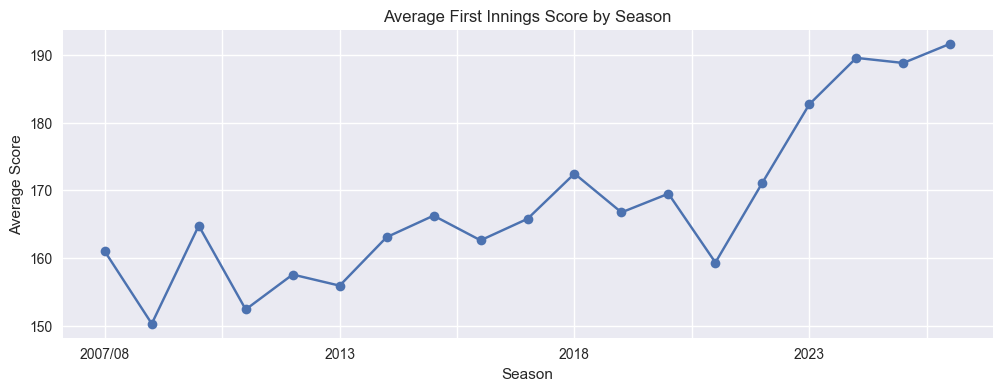

In [13]:
season_avg_scores.plot(
    kind="line",
    figsize=(12, 4),
    marker="o"
)

plt.title("Average First Innings Score by Season")
plt.xlabel("Season")
plt.ylabel("Average Score")

plt.savefig("avg_score_by_season.png", dpi=150)

plt.show()

### Observation

- Average first innings scores have increased significantly over IPL history.
- Earlier IPL seasons had average scores around 150–165, while recent seasons are consistently near 185–190.
- Modern T20 batting has become much more aggressive, especially in powerplay and death overs.

In [14]:
wicket_by_over = (
    df.groupby("over")["is_wicket"]
    .sum()
)

wicket_by_over

over
0      500
1      576
2      626
3      614
4      650
5      601
6      508
7      543
8      605
9      567
10     651
11     633
12     678
13     719
14     781
15     839
16     886
17    1075
18    1109
19    1458
Name: is_wicket, dtype: int64

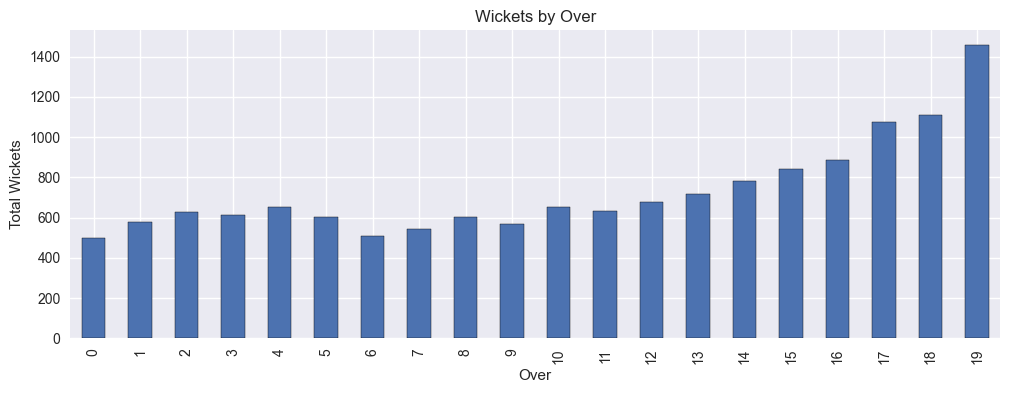

In [15]:
wicket_by_over.plot(
    kind="bar",
    figsize=(12, 4),
    edgecolor="black"
)

plt.title("Wickets by Over")
plt.xlabel("Over")
plt.ylabel("Total Wickets")

plt.savefig("wickets_by_over.png", dpi=150)

plt.show()

### Observation

- Wickets occur more frequently during death overs, especially overs 17–20.
- Batters usually play more aggressively near the end of the innings, increasing wicket chances.
- Powerplay overs also show relatively high wicket frequency compared to middle overs.

In [16]:
top_venues = (
    df["venue"]
    .value_counts()
    .head(10)
)

top_venues

venue
Eden Gardens                                 17988
Wankhede Stadium                             17584
M Chinnaswamy Stadium                        14895
Wankhede Stadium, Mumbai                     14280
Feroz Shah Kotla                             13950
MA Chidambaram Stadium, Chepauk              11751
Rajiv Gandhi International Stadium, Uppal    11591
Dubai International Cricket Stadium          11187
Sawai Mansingh Stadium                       11150
MA Chidambaram Stadium, Chepauk, Chennai      9948
Name: count, dtype: int64

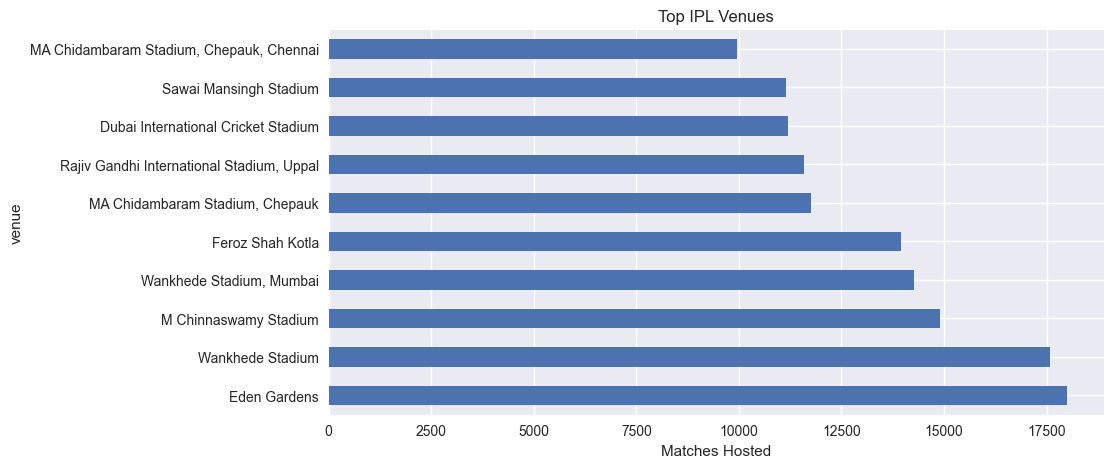

In [17]:
top_venues.plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title("Top IPL Venues")
plt.xlabel("Matches Hosted")

plt.savefig("top_venues.png", dpi=150)

plt.show()

### Observation

- Eden Gardens and Wankhede Stadium have hosted the highest number of IPL matches.
- Some venues repeatedly appear because they are long-term home grounds for franchises.
- Venue-specific conditions could later help improve match prediction models.

In [18]:
first_innings = df[df["innings"] == 1][["match_id", "batting_team"]].drop_duplicates()

first_innings.columns = ["match_id", "team_batted_first"]

winners = df[["match_id", "winner"]].drop_duplicates()

match_result = first_innings.merge(winners, on="match_id")

match_result["batting_first_won"] = (
    match_result["team_batted_first"] == match_result["winner"]
).astype(int)

match_result = match_result[match_result["winner"].notna()]
match_result = match_result[match_result["winner"] != "nan"]

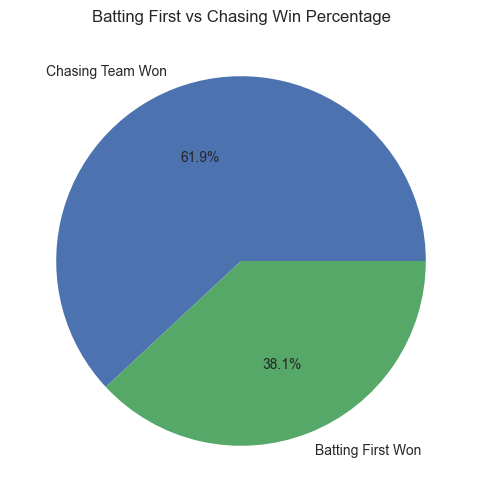

In [19]:
win_counts = match_result["batting_first_won"].value_counts()

labels = ["Chasing Team Won", "Batting First Won"]

plt.figure(figsize=(6, 6))

plt.pie(
    win_counts,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Batting First vs Chasing Win Percentage")

plt.savefig("win_rate_pie.png", dpi=150)

plt.show()

### Observation

- Teams batting second win around 62% of IPL matches.
- Chasing appears to provide a noticeable advantage in IPL games.
- Dew, pitch behavior under lights, and score visibility may contribute to successful chases.

In [20]:
toss_decision = (
    df[["match_id", "toss_decision"]]
    .drop_duplicates()["toss_decision"]
    .value_counts()
)

toss_decision

toss_decision
field    822
bat      417
Name: count, dtype: int64

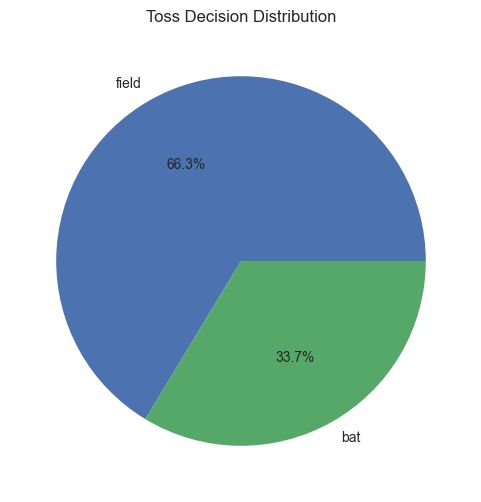

In [21]:
toss_decision.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

plt.title("Toss Decision Distribution")

plt.ylabel("")

plt.savefig("toss_decision.png", dpi=150)

plt.show()

In [22]:
boundary_runs = df[df["runs_off_bat"].isin([4, 6])]["runs_off_bat"].sum()

total_runs = df["total_runs_ball"].sum()

boundary_percentage = (boundary_runs / total_runs) * 100

print(f"Boundary contribution: {boundary_percentage:.2f}%")

Boundary contribution: 57.82%


In [23]:
team_wins = (
    df[["match_id", "winner"]]
    .drop_duplicates()["winner"]
    .value_counts()
    .head(10)
)

team_wins

winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               122
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  46
Name: count, dtype: int64

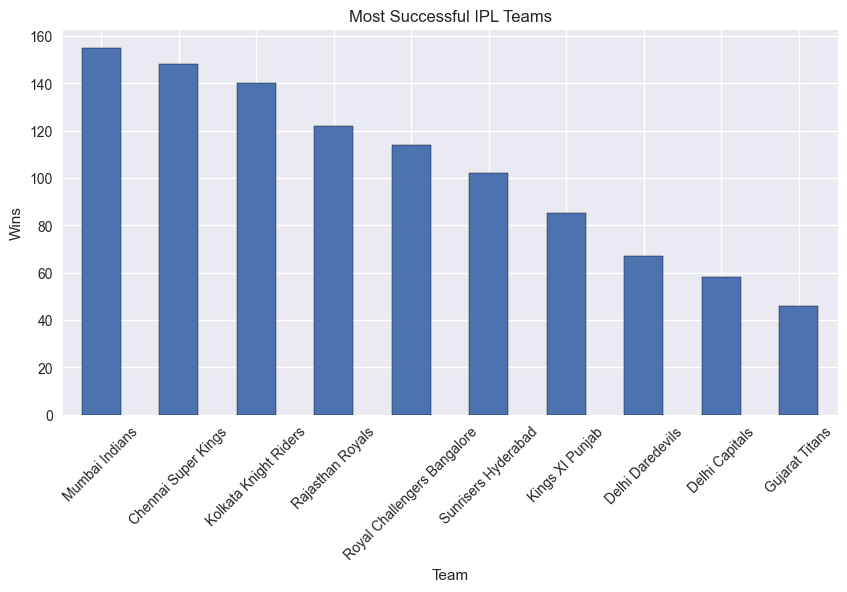

In [24]:
team_wins.plot(
    kind="bar",
    figsize=(10, 5),
    edgecolor="black"
)

plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.savefig("top_teams.png", dpi=150)

plt.show()

In [25]:
toss_match = df[
    ["match_id", "toss_winner", "winner"]
].drop_duplicates()

toss_match["toss_winner_won"] = (
    toss_match["toss_winner"] == toss_match["winner"]
).astype(int)

toss_win_rate = toss_match["toss_winner_won"].mean()

print(f"Toss winner match win rate: {toss_win_rate:.2%}")

Toss winner match win rate: 50.61%


In [26]:
extras = (
    df[["wides", "noballs", "byes", "legbyes"]]
    .sum()
)

extras

wides      11741.0
noballs     1251.0
byes        1380.0
legbyes     5741.0
dtype: float64

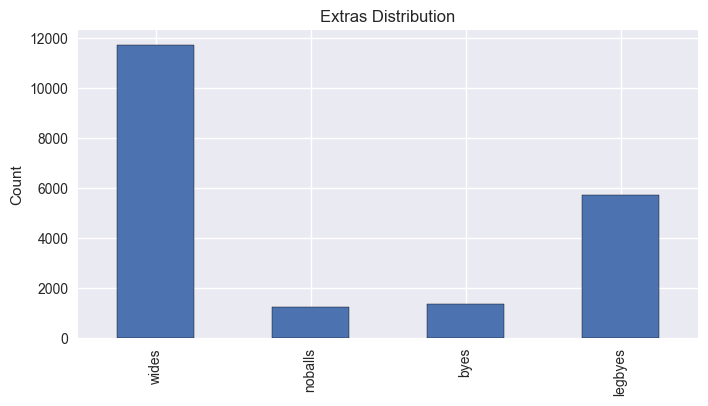

In [27]:
extras.plot(
    kind="bar",
    figsize=(8, 4),
    edgecolor="black"
)

plt.title("Extras Distribution")

plt.ylabel("Count")

plt.savefig("extras_distribution.png", dpi=150)

plt.show()

In [28]:
powerplay = df[df["over"] <= 5]["total_runs_ball"].mean()

middle = df[(df["over"] >= 6) & (df["over"] <= 14)]["total_runs_ball"].mean()

death = df[df["over"] >= 15]["total_runs_ball"].mean()

phase_scores = pd.Series({
    "Powerplay": powerplay,
    "Middle Overs": middle,
    "Death Overs": death
})

phase_scores

Powerplay       1.294561
Middle Overs    1.283935
Death Overs     1.591845
dtype: float64

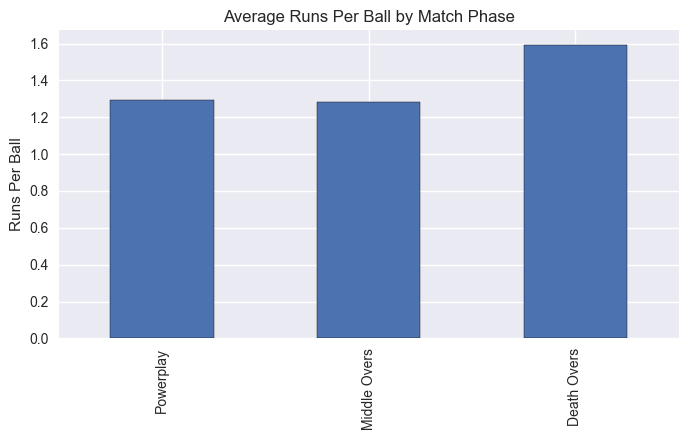

In [29]:
phase_scores.plot(
    kind="bar",
    figsize=(8, 4),
    edgecolor="black"
)

plt.title("Average Runs Per Ball by Match Phase")

plt.ylabel("Runs Per Ball")

plt.savefig("phase_scoring.png", dpi=150)

plt.show()

In [30]:
recent_seasons = df[df["season"] >= "2022"]

older_seasons = df[df["season"] <= "2018"]

recent_avg = (
    recent_seasons[recent_seasons["innings"] == 1]
    .groupby("match_id")["total_runs_ball"]
    .sum()
    .mean()
)

older_avg = (
    older_seasons[older_seasons["innings"] == 1]
    .groupby("match_id")["total_runs_ball"]
    .sum()
    .mean()
)

comparison = pd.Series({
    "2008-2018": older_avg,
    "2022-2026": recent_avg
})

comparison

2008-2018    160.767241
2022-2026    184.677686
dtype: float64

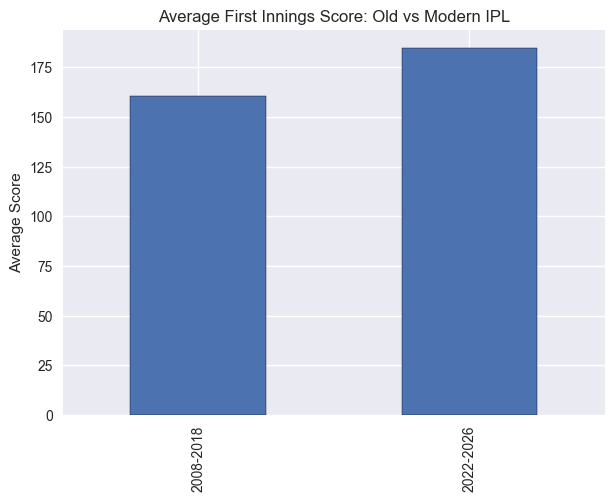

In [31]:
comparison.plot(
    kind="bar",
    figsize=(7, 5),
    edgecolor="black"
)

plt.title("Average First Innings Score: Old vs Modern IPL")

plt.ylabel("Average Score")

plt.savefig("era_comparison.png", dpi=150)

plt.show()

In [36]:
first_innings_totals = (
    df[df["innings"] == 1]
    .groupby(["match_id", "season"])["total_runs_ball"]
    .sum()
    .reset_index()
)

scores_200 = (
    first_innings_totals["total_runs_ball"] >= 200
).sum()

print(f"Total 200+ scores: {scores_200}")

Total 200+ scores: 215


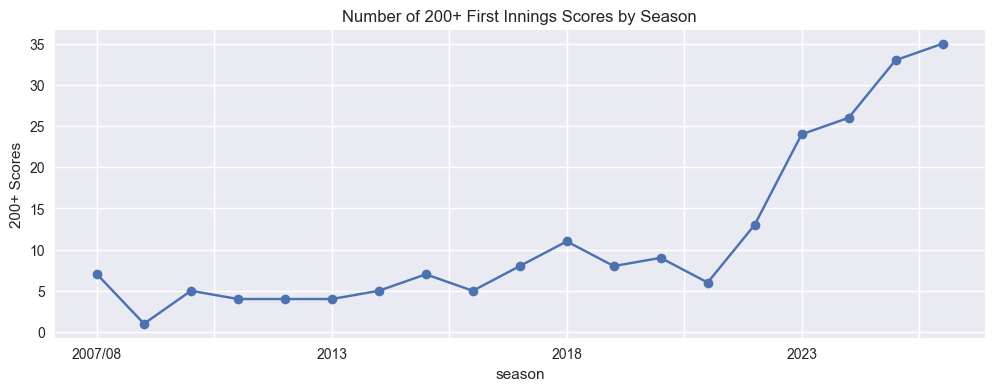

In [43]:
scores_200_by_season = (
    first_innings_totals
    .assign(score_200 = first_innings_totals["total_runs_ball"] >= 200)
    .groupby("season")["score_200"]
    .sum()
)

scores_200_by_season.plot(
    kind="line",
    figsize=(12, 4),
    marker="o"
)

plt.title("Number of 200+ First Innings Scores by Season")

plt.ylabel("200+ Scores")

plt.savefig("200_plus_scores.png", dpi=150)

plt.show()

### Observation

- Modern IPL seasons show a major increase in high-scoring matches.
- Scores above 200 have become significantly more common in recent years.
- Flatter pitches, aggressive batting strategies, deeper batting lineups, and the impact player rule may be contributing factors.
- Bowlers are under much greater pressure compared to earlier IPL seasons.


## Final Conclusion

This exploratory analysis helped identify several important IPL trends:

- Chasing teams have a noticeable advantage.
- Modern IPL seasons are significantly higher scoring.
- Death overs contribute heavily to both runs and wickets.
- Venue and toss decisions may influence match outcomes.
- Ball-by-ball data is clean enough for feature engineering and predictive modelling.

The processed dataset is now ready for building machine learning models and advanced cricket analytics.